# Building Custom Ensembles

TimeCopilot ships a built-in [`MedianEnsemble`](../api/models/ensembles.md) that combines several models by taking the median of their forecasts. But you are not limited to it: any aggregation you can think of can be packaged as a reusable ensemble.

This tutorial shows how to build your own ensemble from scratch and run it with the low-level `TimeCopilotForecaster` API. We'll implement a `WeightedEnsemble` that plugs in your own weighting scheme.

## The ensemble contract

An ensemble in TimeCopilot is just a `Forecaster`. To build your own you only need to:

1. Subclass `Forecaster`.
2. Set `self.alias` (the name of your ensemble's output column).
3. Implement `forecast(...)`, returning a DataFrame with `unique_id`, `ds`, and a column named `self.alias`.

That's it. The base class gives you `cross_validation` and `plot` for free, and your ensemble can be used anywhere a `Forecaster` is expected. The built-in `MedianEnsemble` follows exactly this pattern: it wraps a `TimeCopilotForecaster` internally to get one column per model, then aggregates those columns.

## Imports

In [ ]:
import pandas as pd

from timecopilot import TimeCopilotForecaster
from timecopilot.models.utils.forecaster import Forecaster
from timecopilot.models.foundation.chronos import Chronos
from timecopilot.models.stats import AutoARIMA, SeasonalNaive

## Define a custom `WeightedEnsemble`

Our ensemble takes a list of base models and an optional list of `weights`. Internally it delegates to `TimeCopilotForecaster`, which returns one forecast column per model (named after each model's alias). For every timestamp we then combine those columns into a single prediction by multiplying each model's forecast by its weight and summing the results. When no weights are given, every model gets the same weight, which is just the plain average.

The weights only express *relative* importance, so you do not have to pass fractions that add up to 1. The ensemble normalizes them for you: it divides each weight by the sum of all weights before combining. That is why we can use whole numbers like `[2, 1, 1]` instead of `[0.5, 0.25, 0.25]`. Both mean exactly the same thing: the first model counts twice as much as each of the other two. Writing `[2, 1, 1]` is easier to read and to tweak, and you never have to recompute the fractions when you add or remove a model.

This keeps the example focused on point forecasts. To also produce quantiles, you would aggregate the per-model `{alias}-q-{pct}` columns the same way and use `QuantileConverter`, exactly as the built-in `MedianEnsemble` does.

In [2]:
class WeightedEnsemble(Forecaster):
    def __init__(
        self,
        models: list[Forecaster],
        weights: list[float] | None = None,
        alias: str = "WeightedEnsemble",
    ):
        if weights is not None and len(weights) != len(models):
            raise ValueError("`weights` must have the same length as `models`.")
        self.tcf = TimeCopilotForecaster(models=models, fallback_model=None)
        self.weights = weights
        self.alias = alias

    def forecast(
        self,
        df: pd.DataFrame,
        h: int,
        freq: str | None = None,
        level: list[int | float] | None = None,
        quantiles: list[float] | None = None,
    ) -> pd.DataFrame:
        # one forecast column per base model
        fcst_df = self.tcf.forecast(df=df, h=h, freq=freq)
        model_cols = [model.alias for model in self.tcf.models]
        weights = self.weights or [1.0] * len(model_cols)
        weights = pd.Series(weights, index=model_cols)
        weights = weights / weights.sum()
        out = fcst_df[["unique_id", "ds"]].copy()
        out[self.alias] = fcst_df[model_cols].mul(weights, axis=1).sum(axis=1)
        return out

## Load data

We use the classic AirPassengers series. The DataFrame must contain `unique_id`, `ds`, and `y` columns.

In [3]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/air_passengers.csv",
    parse_dates=["ds"],
)
df.head()

,unique_id,ds,y
0,AirPassengers,1949-01-01,112
1,AirPassengers,1949-02-01,118
2,AirPassengers,1949-03-01,132
3,AirPassengers,1949-04-01,129
4,AirPassengers,1949-05-01,121


## Run your ensemble

We combine a small foundation model (Chronos) with two classic baselines, giving Chronos a larger weight.

In [4]:
models = [
    Chronos(repo_id="amazon/chronos-t5-tiny", alias="Chronos"),
    SeasonalNaive(),
    AutoARIMA(),
]

ensemble = WeightedEnsemble(models=models, weights=[2.0, 1.0, 1.0])
fcst_df = ensemble.forecast(df=df, h=12)
fcst_df.head()

`torch_dtype` is deprecated! Use `dtype` instead!
100%|██████████| 1/1 [00:00<00:00,  3.09it/s]


,unique_id,ds,WeightedEnsemble
0,AirPassengers,1961-01-01,438.240814
1,AirPassengers,1961-02-01,430.611206
2,AirPassengers,1961-03-01,457.616318
3,AirPassengers,1961-04-01,484.624809
4,AirPassengers,1961-05-01,513.398132


## Plot

`plot` is inherited from `Forecaster`, so it works on your custom ensemble out of the box.

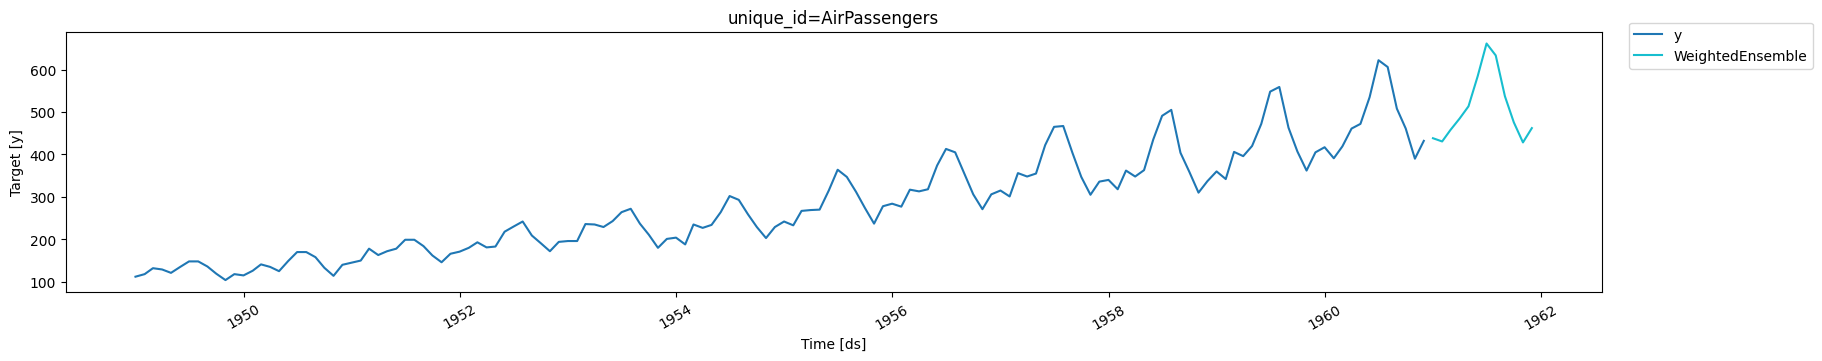

In [5]:
ensemble.plot(df, fcst_df)

## Compare ensembles side by side

Because every ensemble is just a `Forecaster`, you can drop your `WeightedEnsemble` into a `TimeCopilotForecaster` next to the built-in `MedianEnsemble` and any regular model (here `AutoETS`). This runs them together and returns one column per forecaster, so you can compare them directly.

In [6]:
from timecopilot.models.ensembles.median import MedianEnsemble
from timecopilot.models.stats import AutoETS

tcf = TimeCopilotForecaster(
    models=[
        WeightedEnsemble(models=models, weights=[2.0, 1.0, 1.0]),
        MedianEnsemble(models=models),
        AutoETS(),
    ]
)

fcst_df = tcf.forecast(df=df, h=12)
fcst_df.head()

100%|██████████| 1/1 [00:00<00:00, 11.60it/s]


,unique_id,ds,WeightedEnsemble,MedianEnsemble,AutoETS
0,AirPassengers,1961-01-01,434.490509,444.309570,442.357178
1,AirPassengers,1961-02-01,429.840576,418.213745,428.267365
2,AirPassengers,1961-03-01,450.629410,446.243408,492.974792
3,AirPassengers,1961-04-01,481.439613,476.343262,477.369995
4,AirPassengers,1961-05-01,503.482880,499.237061,477.602814


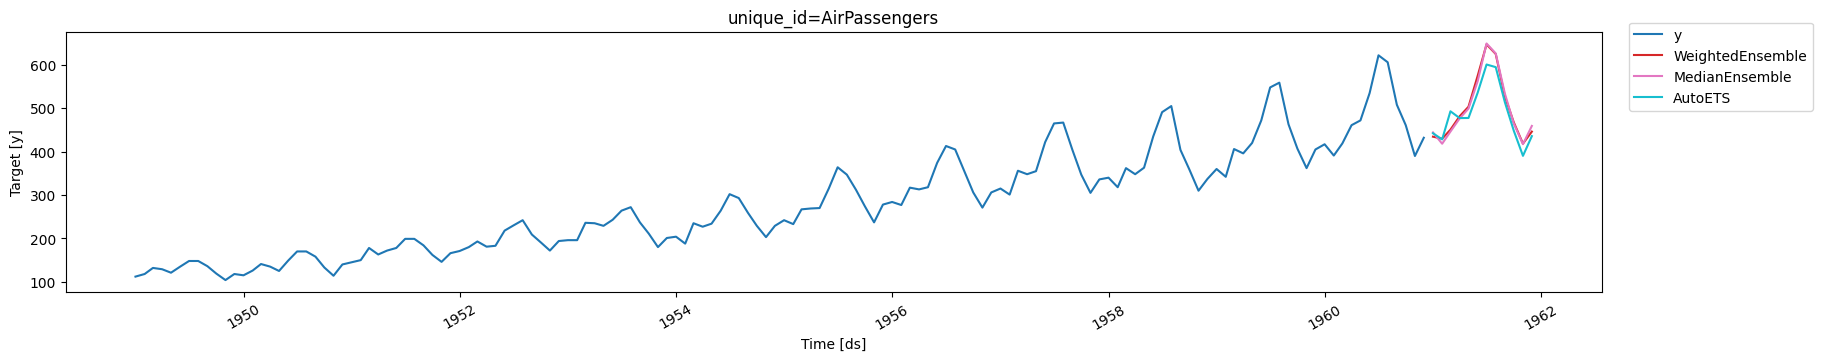

In [7]:
tcf.plot(df, fcst_df)

## Recap

Building a custom ensemble comes down to subclassing `Forecaster`, setting an `alias`, and implementing `forecast`. Because it is a regular `Forecaster`, the same class can be:

- dropped into a `TimeCopilotForecaster(models=[...])` alongside other models,
- passed to the agent via `forecasters=[...]`,
- cross-validated with `ensemble.cross_validation(...)`.

For a complete reference implementation, including probabilistic (quantile) forecasts, see the built-in [`MedianEnsemble`](../api/models/ensembles.md).